In [2]:
import scipy.io
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.io import loadmat
from datetime import datetime
from collections import defaultdict

import torch
import torch_geometric as tg
import torch.nn as nn
from torch_geometric.data import Data

from torch_geometric.utils import to_undirected, remove_self_loops, get_laplacian, to_dense_adj
from torch_geometric.utils import to_scipy_sparse_matrix, dense_to_sparse

/Users/vibhabalaji/anaconda3/envs/GAN_Dec2022_DIGxgraph/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
# MISC
adjmat_112 = scipy.io.loadmat("../data/Input/one_A/A_one_0_w.mat")['A_one']
proximity_112 = scipy.io.loadmat('../data/Input/proximity1e-2.mat')['proximity']

rois_112 = pd.read_csv('../data/Input/roi_names_112.csv', header = None)
rois_112['Atlas index'] = rois_112[[0]]
rois_112['ROI name'] = rois_112[[1,2,3,4]].fillna('').apply(lambda x: ' '.join(x).replace('ctx ',
                                                                        '').strip(), axis = 1)
rois_112 = rois_112[['Atlas index', 'ROI name']]
rois_112['Hemisphere'] = rois_112['ROI name'].str.extract(r'(\blh\b|\brh\b)')
rois_112['Hemisphere'] = rois_112['Hemisphere'].map({'lh': 'left', 'rh': 'right'})
rois_112['ROI name'] = rois_112['ROI name'].str.replace(r'\blh\b|\brh\b', '', regex=True).str.strip()

# Get subset of 66 ROIs from subset of 85 ROIs
nwm_85 = scipy.io.loadmat('../data/Input/nwm.mat')['nwm'][0]-1 
map_85_to_66 = scipy.io.loadmat('../data/Input/rois_vog_66_nwm.mat')['rois_vog_66_nwm']-1
subset_rois_66 = [nwm_85[index] for index in map_85_to_66.flatten()]


open_file = open('../data/66 ROIs processing/subset_rois_66.pkl', "wb")
pkl.dump(subset_rois_66, open_file)
open_file.close()

n_rois = 66

# Adjacency matrix
adjmat_66 = adjmat_112[np.ix_(subset_rois_66, subset_rois_66)]
# ROI names
rois_66 = rois_112.loc[subset_rois_66].reset_index(drop=True)
meta_rois_66 = rois_66[rois_66['ROI name'].isin(['entorhinal', 'Amygdala', 'parahippocampal', 
                                        'fusiform', 'inferiortemporal', 'middletemporal'])]

In [18]:
def scale(data):
    scaled_data = (data - np.min(data))/(np.max(data) - np.min(data))
    limits = (np.min(data), np.max(data))
#     scaled_data = (data - np.mean(data)) / (np.std(data) + 1e-8)
#     limits = (np.mean(data), np.std(data))
    return scaled_data, limits

def scale_with_different_limits(data, limits):
    scaled_data = (data - limits[0])/(limits[1] - limits[0])
#     scaled_data = (data - np.mean(data)) / (np.std(data) + 1e-8)
    return scaled_data, limits

def annualize(age1, age2, data1, data2):
    annualized_data2 = data1 + (data2 - data1)/(age2 - age1)
    return annualized_data2

def remove_negative_dsuvr(data1, data2):
    data1, data2 = np.array(data1), np.array(data2)
    nonneg_mask = (data2 - data1) >= 0
    nondec_data2 = np.where(nonneg_mask, data2, data1)
    return nondec_data2

In [4]:
# HABS

In [7]:
habs_data = pd.read_csv("../data/Input/HABS_all_tau_and_Ab.csv")
habs_dti = pd.read_excel("../data/Input/datalist_149.xlsx")
habs_connectome = loadmat("../data/Input/HABSdataset_62.mat")
habs_clinical = pd.read_excel("../data/Input/HABS_Tau_subjects_filled.xlsx")

In [17]:
list(set(habs_dti['Tscore'].to_list())-set(habs_connectomes_subs))

['T206', 'T054', 'T114', 'T200', 'T250', 'T066', 'T202']

In [13]:
habs_dti

,SubjIDshort,Tscore,MRI_Session_ID.HAB_1.0,MRI_SessionDate.HAB_1.0,MRI_Age.HAB_1.0,MRI_Session_Name.HAB_1.0,MRI_Session_ID.HAB_4.0,MRI_SessionDate.HAB_4.0,MRI_Age.HAB_4.0,MRI_Session_Name.HAB_4.0,Unnamed: 10,PET time1,PET time2,M1 - P1,M2 - P1,P2-P1,abs(N)-abs(O)
0,S_AUL7R4,T005,701,2010-11-04,72.00,101104_4TT01189,1785,2013-12-10,75.25,131210_3TT00839,NaN,2013-07-26,2015-12-18,-995,137,875,858
1,S_NIQUVD,T084,734,2010-12-09,80.75,101209_4TT01201,2038,2014-02-12,83.75,140212_3TT00864,NaN,2014-02-27,2016-01-25,-1176,-15,697,1161
2,S_V36DLL,T077,739,2011-01-06,83.75,110106_4TT01210,1750,2013-11-26,86.75,131126_3TT00837,NaN,2014-02-11,2016-02-11,-1132,-77,730,1055
3,S_2BB4H2,T102,744,2011-01-20,75.50,110120_4TT01212,1834,2013-12-31,78.50,131231_3TT00849,NaN,2014-02-19,2016-12-19,-1126,-50,1034,1076
4,S_6FWKZD,T101,745,2011-01-20,68.25,110120_4TT01213,1835,2013-12-31,71.00,131231_3TT00850,NaN,2014-02-19,2016-12-16,-1126,-50,1031,1076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,S_YEFGQ2,T107,1576,2013-07-25,74.25,130725_4TT01510,2984,2016-06-15,77.00,160615_3TT01024,NaN,2014-01-10,2016-07-07,-169,887,909,-718
65,S_FDJ6UU,T075,1587,2013-08-08,65.75,130808_4TT01514,3029,2016-08-03,68.75,160802_3TT01030,NaN,2013-12-04,2016-08-01,-118,973,971,-855
66,S_LABYUQ,T097,1629,2013-09-26,72.50,130926_4TT01535,3546,2016-11-02,75.50,161102_3TT01056,NaN,2014-01-07,2017-01-26,-103,1030,1115,-927
67,S_XTDEMR,T182,1677,2013-10-26,71.25,131026_4TT01554,3570,2016-11-17,74.25,161117_3TT01064,NaN,2014-08-14,2017-03-20,-292,826,949,-534


In [14]:
habs_connectomes_subs = [x[0][0] for x in habs_connectome['sub_codes_62']]

In [18]:
tscore_map = dict(zip(habs_dti['SubjIDshort'], habs_dti['Tscore']))
habs_data['Tscore'] = habs_data['SubjIDshort'].map(tscore_map)
habs_data

,TAU_Session_ID,SubjIDshort,TAU_SessionDate,StudyArc,TAU_Age,TAU_timepoint,TAU_FS_SUVR_Accumbens_area_lh,TAU_FS_SUVR_Accumbens_area_rh,TAU_FS_SUVR_Accumbens_area_bh,TAU_FS_SUVR_Air,...,PIB_FS_DVR_supramarginal_bh,PIB_FS_DVR_supramarginal_lh,PIB_FS_DVR_supramarginal_rh,PIB_FS_DVR_temporalpole_bh,PIB_FS_DVR_temporalpole_lh,PIB_FS_DVR_temporalpole_rh,PIB_FS_DVR_transversetemporal_bh,PIB_FS_DVR_transversetemporal_lh,PIB_FS_DVR_transversetemporal_rh,Tscore
0,192,S_11XDXA,03-10-2014,HAB_4.0,72.00,1,1.251217,1.172393,1.205427,0.492346,...,1.1768,1.18460,1.1696,0.92149,0.96091,0.86841,1.3224,1.4038,1.1976,T192
1,513,S_11XDXA,23-09-2016,HAB_6.0,74.00,2,1.204565,1.263520,1.232882,0.420727,...,1.1066,1.10810,1.1030,0.87891,0.89313,0.85718,1.2830,1.3140,1.2377,T192
2,1367,S_11XDXA,13-12-2019,HAB_9.0,77.25,3,1.279997,1.189762,1.228959,0.434685,...,1.1294,1.12050,1.1372,0.75817,0.75951,0.75995,1.2407,1.2731,1.1918,T192
3,984,S_17US4N,08-05-2018,HAB_1.0,65.50,1,1.102177,1.035415,1.064306,0.613107,...,1.0563,1.08210,1.0266,0.86063,0.79874,0.89906,1.2195,1.2421,1.1819,NaN
4,1458,S_17US4N,26-02-2021,HAB_4.0,68.25,2,1.024717,1.072508,1.054771,0.578781,...,1.0681,1.05710,1.0767,0.86611,0.78871,0.91733,1.2481,1.2696,1.2109,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,1208,S_ZNUP4E,02-07-2019,HAB_9.0,78.75,3,1.175553,1.143262,1.157596,0.472938,...,1.8888,1.92850,1.8396,1.18380,1.21470,1.10300,1.8148,1.8554,1.6257,T189
427,24,S_ZPBHLL,05-09-2013,HAB_3.0,69.00,1,1.053799,1.099519,1.078377,0.694276,...,1.0819,1.04310,1.1213,0.83126,0.80724,0.80851,1.3184,1.3215,1.2968,NaN
428,300,S_ZPBHLL,09-09-2015,HAB_5.0,71.00,2,1.005953,0.997704,1.001871,0.611677,...,1.0301,0.94533,1.1261,0.81982,0.78533,0.84207,1.1396,1.1025,1.1724,NaN
429,456,S_ZPBHLL,09-06-2016,HAB_6.0,71.75,3,0.954748,0.870976,0.913470,0.575298,...,1.0075,0.95769,1.0613,0.81010,0.74666,0.86220,1.0900,1.1146,1.0653,NaN


In [19]:
ab_pos_data = habs_data[habs_data['PIB_FS_DVR_Group'] == 'PIB+']
def count_abplus_and_dti(tp1, tp2):
    subject_timepoints = ab_pos_data.groupby('SubjIDshort')['TAU_timepoint'].apply(set)
    qualifying_subjects = subject_timepoints[subject_timepoints.apply(lambda tps: tp1 in tps and tp2 in tps)].index
    total = len(qualifying_subjects)
    with_dti = habs_data[habs_data['SubjIDshort'].isin(qualifying_subjects) & habs_data['Tscore'].notna()]['SubjIDshort'].nunique()
    return total, with_dti

In [20]:
count_abplus_and_dti(1, 2), count_abplus_and_dti(2, 3), count_abplus_and_dti(3, 4)

((39, 21), (17, 13), (3, 0))

In [21]:
ab_pos_data

,TAU_Session_ID,SubjIDshort,TAU_SessionDate,StudyArc,TAU_Age,TAU_timepoint,TAU_FS_SUVR_Accumbens_area_lh,TAU_FS_SUVR_Accumbens_area_rh,TAU_FS_SUVR_Accumbens_area_bh,TAU_FS_SUVR_Air,...,PIB_FS_DVR_supramarginal_bh,PIB_FS_DVR_supramarginal_lh,PIB_FS_DVR_supramarginal_rh,PIB_FS_DVR_temporalpole_bh,PIB_FS_DVR_temporalpole_lh,PIB_FS_DVR_temporalpole_rh,PIB_FS_DVR_transversetemporal_bh,PIB_FS_DVR_transversetemporal_lh,PIB_FS_DVR_transversetemporal_rh,Tscore
5,201,S_1GQ9QV,22-10-2014,HAB_5.0,76.00,1,1.037635,1.060653,1.049184,0.811178,...,1.6569,1.5529,1.7658,1.10180,0.99785,1.16000,1.6120,1.4827,1.7918,T202
6,363,S_1GQ9QV,05-01-2016,HAB_6.0,77.25,2,1.198352,1.122703,1.155089,0.713111,...,1.6260,1.5867,1.6635,1.10480,1.04130,1.16070,1.5476,1.4892,1.6211,T202
7,94,S_1KQGRZ,27-02-2014,HAB_4.0,79.25,1,1.120696,1.145626,1.132553,0.486768,...,1.6109,1.6471,1.5444,1.10820,1.03380,1.15960,1.4815,1.4792,1.4530,T092
8,372,S_1KQGRZ,28-01-2016,HAB_6.0,81.25,2,1.176121,1.094407,1.134470,0.435065,...,1.5360,1.6227,1.4378,1.01790,1.16760,0.87536,1.4328,1.4512,1.3251,T092
9,1114,S_1KQGRZ,18-12-2018,HAB_9.0,84.25,3,1.007981,1.112754,1.059077,0.423412,...,1.7326,1.6993,1.7706,1.10030,0.99242,1.20220,1.5255,1.5261,1.4915,T092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,168,S_ZASXXZ,11-08-2014,HAB_4.0,88.25,1,1.105449,1.218763,1.155428,0.390799,...,1.6369,1.6320,1.6373,1.03040,0.93183,1.10010,1.5629,1.5011,1.5846,T180
421,511,S_ZASXXZ,15-09-2016,HAB_6.0,90.25,2,1.092374,1.200949,1.146617,0.610902,...,1.6496,1.6667,1.6294,0.98059,0.91303,1.02420,1.5444,1.5680,1.4348,T180
424,179,S_ZNUP4E,19-09-2014,HAB_4.0,74.00,1,1.136645,1.064015,1.097351,0.583896,...,1.7404,1.7999,1.6734,1.12630,1.07670,1.12810,1.6173,1.7248,1.4031,T189
425,521,S_ZNUP4E,05-10-2016,HAB_6.0,76.00,2,1.093256,1.167073,1.134571,0.524483,...,1.6691,1.7560,1.5702,1.16360,1.12220,1.18640,1.5505,1.6236,1.3913,T189


In [24]:
habs_extracted_data = []
for index, row in habs_data.iterrows():
    try:
        subid = row['SubjIDshort']
        tp = row['TAU_timepoint']
        age = row['TAU_Age']
        session_id = row['TAU_Session_ID']
        session_date = row['TAU_SessionDate']
        tau, ab = [], []
        sub_scaling = row['TAU_FS_SUVR_Cerebellum_White_Matter_bh']
        ab_status = 1.0 if row['PIB_FS_DVR_Group'] == 'PIB+' else 0.0
        for roi_index in range(66):
            roi_name = rois_66['ROI name'].loc[roi_index]
            roi_hemisphere = 'lh' if rois_66.loc[roi_index, 'Hemisphere']=='left' else 'rh'
            tau.append(row[f'TAU_FS_SUVR_{roi_name}_{roi_hemisphere}'])
            ab.append(row[f'PIB_FS_DVR_{roi_name}_{roi_hemisphere}'])
        tau = np.array(tau)/sub_scaling
        ab = np.array(ab)
        tau_status = 1.0 if tau[meta_rois_66.index.tolist()].mean()>=1.27 else 0.0
        extracted_row = {'Subject ID': subid, 'timepoint': tp, 
                         'Age': age,'Session ID': session_id, 'Session date': session_date,
                         'Tau status':tau_status, 'Ab status': ab_status,
                        'Tau': tau,'Ab': ab}
        habs_extracted_data.append(extracted_row)
    except Exception as e:
        print(f'Subject {subid} error: {e}')

habs_extracted_data = pd.DataFrame(habs_extracted_data)

In [34]:
habs_extracted_data

,Subject ID,timepoint,Age,Session ID,Session date,Tau status,Ab status,Tau,Ab
0,S_11XDXA,1,72.00,192,03-10-2014,0.0,0.0,"[1.258414582859521, 1.2483255621214442, 1.1912...","[1.3437, 1.2294, 1.2643, 1.2096, 1.4015, 1.158..."
1,S_11XDXA,2,74.00,513,23-09-2016,0.0,0.0,"[1.1264120034498393, 1.1652151415399787, 1.163...","[1.2327, 1.2229, 1.2579, 1.281, 1.2023, 1.1338..."
2,S_11XDXA,3,77.25,1367,13-12-2019,0.0,0.0,"[1.1742842363050179, 1.1861848920685925, 1.207...","[1.152, 1.1057, 1.2108, 1.1547, 1.2093, 1.1685..."
3,S_17US4N,1,65.50,984,08-05-2018,0.0,0.0,"[1.243130875089537, 1.104211858627084, 1.22297...","[1.1645, 1.0996, 1.1915, 1.1193, 1.1093, 1.186..."
4,S_17US4N,2,68.25,1458,26-02-2021,0.0,0.0,"[1.3397093306771828, 1.142522269633992, 1.3064...","[1.2208, 1.1403, 1.1682, 1.1802, 1.1993, 1.217..."
...,...,...,...,...,...,...,...,...,...
426,S_ZNUP4E,3,78.75,1208,02-07-2019,0.0,1.0,"[1.1754037270085065, 1.2239337472117204, 1.138...","[1.2217, 1.3701, 1.1959, 1.3024, 2.1654, 1.945..."
427,S_ZPBHLL,1,69.00,24,05-09-2013,0.0,0.0,"[1.0814604155406133, 1.1071461324602447, 1.185...","[1.2411, 1.1701, 1.2395, 1.2238, 1.2504, 1.209..."
428,S_ZPBHLL,2,71.00,300,09-09-2015,0.0,0.0,"[1.0530582837630873, 1.084586974697104, 1.1140...","[1.156, 1.1344, 1.1151, 1.1314, 1.2073, 1.1274..."
429,S_ZPBHLL,3,71.75,456,09-06-2016,0.0,0.0,"[1.075517333915804, 1.1241601718272658, 1.1212...","[1.1511, 1.1931, 1.0819, 1.1096, 1.179, 1.0976..."


In [36]:
# tau  = habs_extracted_data.copy()
# clin = habs_clinical.copy()

# # parse dates
# tau["Session date"]   = pd.to_datetime(tau["Session date"], format="mixed", dayfirst=True)
# clin["NP_SessionDate"] = pd.to_datetime(clin["NP_SessionDate"], format="mixed", dayfirst=True)

# # keep original order
# tau["_orig_idx"] = np.arange(len(tau))

# # drop bad dates
# tau  = tau.dropna(subset=["Session date"])
# clin = clin.dropna(subset=["NP_SessionDate"])

# # IMPORTANT: sort by the ON key first (global sort), then by subject
# tau  = tau.sort_values(["Session date", "Subject ID"], kind="mergesort").reset_index(drop=True)
# clin = clin.sort_values(["NP_SessionDate", "SubjIDshort"], kind="mergesort").reset_index(drop=True)

# merged_habs = pd.merge_asof(
#     tau, clin,
#     left_on="Session date", right_on="NP_SessionDate",
#     left_by="Subject ID", right_by="SubjIDshort",
#     direction="backward"
# )

# # restore original order
# merged_habs = merged_habs.sort_values("_orig_idx").drop(columns="_orig_idx").reset_index(drop=True)
# merged_habs.to_pickle("habs_66rois_with_clinical.pkl")

In [706]:
# Group by Tau and Ab status, then count unique subjects
subject_counts = (
    habs_extracted_data
    .groupby(['Tau status', 'Ab status'])['Subject ID']
    .nunique()
    .reset_index(name='Unique Subjects')
)

print(subject_counts)

   Tau status  Ab status  Unique Subjects
0         0.0        0.0              139
1         0.0        1.0               46
2         1.0        0.0                2
3         1.0        1.0               13


In [722]:
habs_paired_data = []
habs_extracted_data = habs_extracted_data.sort_values(['Subject ID', 'timepoint'])
for subid, group in habs_extracted_data.groupby('Subject ID'):
    group = group.reset_index(drop = True)
    if len(group) < 2:
        print(f'Skipping subject {subid} with 1 timepoint only')
        continue
    for i in range(len(group)-1):
        tp1 = group.loc[i]
        tp2 = group.loc[i+1]
        
        if tp2['timepoint'] - tp1['timepoint'] == 1:
            age_diff = tp2['Age']-tp1['Age']
            ann_tau = tp1['Tau'] + (tp2['Tau']-tp1['Tau'])/age_diff
            scale = np.array([tp1['Tau'].min(), tp1['Tau'].max()])
            scale_tp1 = (tp1['Tau']-scale[0])/(scale[1]-scale[0])
            scale_tp2 = (ann_tau-scale[0])/(scale[1]-scale[0])
            paired_row = {
                'Subject ID': subid,
                'tp1': tp1['timepoint'], 'tp2': tp2['timepoint'],
                'Age1': tp1['Age'], 'Age2': tp2['Age'], 'Age difference': age_diff,
                'Tau tp1': tp1['Tau'], 'Tau tp2': tp2['Tau'], 'Annualized Tau tp2': ann_tau,
                'Scaled Tau tp1': scale_tp1, 'Scaled Tau tp2': scale_tp2, 
                'Scale Limits': scale, 'dSUVR': scale_tp2-scale_tp1,
                'Session ID tp1': tp1['Session ID'], 'Session ID tp2': tp2['Session ID'],
                'Tau status': tp1['Tau status'], 'Ab status': tp1['Ab status'],
            }
            habs_paired_data.append(paired_row)
habs_paired_data = pd.DataFrame(habs_paired_data)

In [921]:
nan_rows = set(habs_paired_data[habs_paired_data.isna().any(axis=1)]['Session ID tp1'])
habs_paired_data = habs_paired_data[~habs_paired_data['Session ID tp1'].isin(nan_rows)]

In [723]:
habs_paired_data

,Subject ID,tp1,tp2,Age1,Age2,Age difference,Tau tp1,Tau tp2,Annualized Tau tp2,Scaled Tau tp1,Scaled Tau tp2,Scale Limits,dSUVR,Session ID tp1,Session ID tp2,Tau status,Ab status
0,S_11XDXA,1,2,72.00,74.00,2.00,"[1.258414582859521, 1.2483255621214442, 1.1912...","[1.1264120034498393, 1.1652151415399787, 1.163...","[1.1924132931546803, 1.2067703518307114, 1.177...","[1.0, 0.9763089787667921, 0.8423253042882288, ...","[0.8450158844539605, 0.8787291050697703, 0.809...","[0.8325561684516624, 1.258414582859521]","[-0.15498411554603952, -0.09757987369702181, -...",192,513,0.0,0.0
1,S_11XDXA,2,3,74.00,77.25,3.25,"[1.1264120034498393, 1.1652151415399787, 1.163...","[1.1742842363050179, 1.1861848920685925, 1.207...","[1.1411419212514327, 1.1716673724718598, 1.176...","[0.7701612914573848, 0.8911290315155384, 0.885...","[0.8160814142980144, 0.9112436880247579, 0.927...","[0.8793653534112886, 1.2001379666012628]","[0.04592012284062963, 0.02011465650921951, 0.0...",513,1367,0.0,0.0
2,S_17US4N,1,2,65.50,68.25,2.75,"[1.243130875089537, 1.104211858627084, 1.22297...","[1.3397093306771828, 1.142522269633992, 1.3064...","[1.2782503134850445, 1.1181429171750505, 1.253...","[1.0, 0.6170424815688296, 0.9444375251740106, ...","[1.0968136207635404, 0.6554461770923332, 1.028...","[0.8803778025514896, 1.243130875089537]","[0.09681362076354039, 0.038403695523503645, 0....",984,1458,0.0,0.0
3,S_1GQ9QV,1,2,76.00,77.25,1.25,"[1.3634807411708585, 1.2745601518236918, 1.267...","[1.3062178139478442, 1.3237650193090174, 1.303...","[1.317670399392447, 1.3139240458119523, 1.2964...","[0.5827138104973708, 0.46968872782085963, 0.46...","[0.5244852528038407, 0.5197233419091921, 0.497...","[0.905040417809541, 1.6917736564983912]","[-0.05822855769353008, 0.050034614088332485, 0...",201,363,1.0,1.0
4,S_1KQGRZ,1,2,79.25,81.25,2.00,"[1.369755562980362, 1.4881430133643174, 1.2968...","[1.2448756492291257, 1.393459050882221, 1.2499...","[1.3073156061047437, 1.4408010321232694, 1.273...","[0.8093083378167418, 1.0, 0.6919257214401693, ...","[0.708733664364054, 0.9237442730236586, 0.6541...","[0.8673112002240924, 1.4881430133643174]","[-0.10057467345268778, -0.07625572697634142, -...",94,372,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,S_ZNUP4E,1,2,74.00,76.00,2.00,"[1.1450830139040356, 1.1564069806009405, 1.146...","[1.2228009744918553, 1.1786104342620398, 1.132...","[1.1839419941979454, 1.16750870743149, 1.13988...","[0.8473565125064852, 0.8747171356227715, 0.851...","[0.9412463960572255, 0.9015407895490632, 0.834...","[0.7943805870167873, 1.2082588327269295]","[0.09388988355074024, 0.026823653926291713, -0...",179,521,0.0,1.0
250,S_ZNUP4E,2,3,76.00,78.75,2.75,"[1.2228009744918553, 1.1786104342620398, 1.132...","[1.1754037270085065, 1.2239337472117204, 1.138...","[1.2055656117706375, 1.1950916389710147, 1.134...","[1.0, 0.8959734197424745, 0.7883869946956112, ...","[0.9594271571684333, 0.9347709396524508, 0.793...","[0.7980005040695984, 1.2228009744918553]","[-0.0405728428315667, 0.038797519909976375, 0....",521,1208,0.0,1.0
251,S_ZPBHLL,1,2,69.00,71.00,2.00,"[1.0814604155406133, 1.1071461324602447, 1.185...","[1.0530582837630873, 1.084586974697104, 1.1140...","[1.0672593496518503, 1.0958665535786745, 1.149...","[0.7254293179637129, 0.7933443271161267, 1.0, ...","[0.6878806085846012, 0.7635202538627253, 0.905...","[0.8071002654212054, 1.1853041004819933]","[-0.0375487093791117, -0.029824073253401417, -...",24,300,0.0,0.0
252,S_ZPBHLL,2,3,71.00,71.75,0.75,"[1.0530582837630873, 1.084586974697104, 1.1140...","[1.075517333915804, 1.1241601718272658, 1.1212...","[1.0830036839667094, 1.1373512375373198, 1.123...","[0.716038363093515, 0.816836104945279, 0.91100...","[0.81177429852101, 0.9855243183537367, 0.94191...","[0.829087470209792, 1.1418791097326657]","[0.09573593542749503, 0.16868821340845763, 0.0...",300,456,0.0,0.0


In [42]:
#ADNI

In [29]:
adni_data = pd.read_excel("../data/Input/UCBERKELEY_TAU_6MM_11Feb2025.xlsx")
adni_data = adni_data[adni_data['TRACER']=='FTP']

In [30]:
adni_data

,LONIUID,RID,VISCODE,SITEID,PTID,SCANDATE,PROCESSDATE,IMAGE_RESOLUTION,qc_flag,TRACER,...,RIGHT_PALLIDUM_VOLUME,RIGHT_PUTAMEN_SUVR,RIGHT_PUTAMEN_VOLUME,RIGHT_THALAMUS_PROPER_SUVR,RIGHT_THALAMUS_PROPER_VOLUME,RIGHT_VENTRALDC_SUVR,RIGHT_VENTRALDC_VOLUME,RIGHT_VESSEL_SUVR,RIGHT_VESSEL_VOLUME,update_stamp
0,I1594604,21,init,11,011_S_0021,2018-02-02,2022-09-02,6mm,2,FTP,...,1623.0,1.473,4225.0,1.447,5781.0,1.399,3422.0,1.315,14.0,2024-04-03 12:57:55
1,I1596177,31,init,23,023_S_0031,2018-04-24,2022-09-02,6mm,2,FTP,...,2126.0,1.496,5712.0,1.197,6261.0,1.325,2959.0,1.547,6.0,2024-04-03 12:57:55
2,I1596172,31,y1,23,023_S_0031,2019-04-23,2022-09-02,6mm,2,FTP,...,2156.0,1.411,5967.0,1.134,5947.0,1.241,3008.0,1.438,8.0,2024-04-03 12:57:55
3,I1598898,56,init,67,067_S_0056,2018-02-20,2022-09-02,6mm,2,FTP,...,1551.0,1.765,4024.0,1.398,6595.0,1.431,3646.0,1.584,42.0,2024-04-03 12:57:55
4,I1598985,56,y1,67,067_S_0056,2019-01-10,2022-09-02,6mm,2,FTP,...,1671.0,1.753,4155.0,1.455,6386.0,1.474,3681.0,1.433,39.0,2024-04-03 12:57:55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,I11059591,10293,NaN,21,021_S_10293,2024-11-05,2025-01-14,6mm,2,FTP,...,1631.0,1.328,4292.0,1.116,6772.0,1.243,3302.0,1.271,43.0,2025-01-30 15:07:37
1886,I11060566,10314,NaN,36,036_S_10314,2024-11-13,2025-01-22,6mm,2,FTP,...,1778.0,1.711,3431.0,1.223,5793.0,1.336,3274.0,1.514,9.0,2025-01-30 15:07:37
1887,I11080692,10316,NaN,27,027_S_10316,2024-12-02,2025-01-15,6mm,2,FTP,...,2024.0,1.082,4127.0,1.048,5956.0,1.147,3422.0,1.246,7.0,2025-01-30 15:07:37
1888,I11073463,10322,NaN,36,036_S_10322,2024-11-20,2025-01-14,6mm,2,FTP,...,1784.0,1.988,3552.0,1.504,6367.0,1.474,3593.0,2.159,10.0,2025-01-30 15:07:37


In [31]:
adni_rois_85 = pd.read_excel("../data/Input/roi85 list.xlsx", header = None)
adni_rois_85.columns = ['Column name', 'Code in atlas', 'Name', 'Index in atlas', 'Col5', 'Col6']
adni_rois_66 = adni_rois_85.iloc[map_85_to_66.flatten().tolist()].reset_index(drop=True)

In [32]:
adnidata_struct = loadmat("../data/Input/ADNI_nonPVC_clean.mat")['data'][0]
# adni_abpos_subs = loadmat("../data/Input/ADNI_nonPVC_abeta_pos.mat")['abeta_sub'].flatten()-1
adni_clinical = pd.DataFrame(adnidata_struct)
adni_clinical['subjectID'] = adni_clinical['subjectID'].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x)
adni_clinical['dob'] = adni_clinical['dob'].apply(
    lambda x: pd.to_datetime(x[0][0], format='%m/%Y') if isinstance(x, (list, np.ndarray)) else pd.NaT
)
# adni_abpos_subs = adni_clinical.iloc[adni_abpos_subs.tolist()]['subjectID'].values.tolist()
adni_ab_data = pd.read_csv("../data/Input/UCBERKELEY_AMY_6MM_18Nov2025.csv")
ab_pos_map = adni_ab_data.set_index('PTID')['AMYLOID_STATUS_COMPOSITE_REF'].to_dict()
# adni_abpos_subs = adni_ab_data[adni_ab_data['AMYLOID_STATUS_COMPOSITE_REF']==1.0]['PTID'].values.tolist()

adni_blood = pd.read_csv("../data/Input/ADNI_blood.csv")
adni_dti = pd.read_csv("../data/Input/DTI_Connectome_ADNI.csv")

In [33]:
def unwrap(x):
    """Convert matlab-ish nested 1-element lists/arrays into a scalar.
       Keeps real sequences as lists (e.g., longitudinal mmse)."""
    if x is None:
        return np.nan

    # pandas sometimes stores matlab cells as ndarray(dtype=object)
    if isinstance(x, np.ndarray):
        x = x.tolist()

    # unwrap chains of length-1 containers
    while isinstance(x, (list, tuple)) and len(x) == 1:
        x = x[0]
        if isinstance(x, np.ndarray):
            x = x.tolist()

    return x

In [34]:
# #add empty rows to adni_extracted_data for sex, mmse, cog, diagn, apoe.
# for row in adni_extracted_data:
#     get subject id and scan date
#     find subject id in adni_clinical
#     get sex and apoe from adni_clinical
#     for each among mmse, cog, diagn:
#         extract all the dates and values
#         find the closest more recent date compared with scan
#     update adni_extracted_data row
    

In [35]:
adni_clinical

,subjectID,tau_pet,tau_tp,edu,dob,sex,eth,mmse,cog,diagn,apoe
0,011_S_0021,"[[[['2018-02-02'], [[1.422 1.313 1.476 1.616 1...",[[1]],[[18]],"DatetimeIndex(['1933-02-01'], dtype='datetime6...",[[2]],[[2]],"[[[['2005-09-28'], [[30]]], [['2006-04-24'], [...","[[[['2005-10-24'], [[0.204]], [[1.804]], [[0.6...","[[[['2005-11-01'], [[1]]], [['2006-04-24'], [[...",[[0]]
1,023_S_0031,"[[[['2018-04-24'], [[1.188 1.067 1.469 1.51 0...",[[2]],[[18]],"DatetimeIndex(['1928-01-01'], dtype='datetime6...",[[2]],[[2]],"[[[['2005-10-03'], [[30]]], [['2006-04-18'], [...","[[[['2005-10-24'], [[0.543]], [[2.908]], [[1.0...","[[[['2005-10-24'], [[1]]], [['2006-04-18'], [[...",[[0]]
2,067_S_0056,"[[[['2018-02-20'], [[1.417 1.324 1.743 1.854 1...",[[3]],[[13]],"DatetimeIndex(['1936-03-01'], dtype='datetime6...",[[2]],[[2]],"[[[['2005-10-25'], [[28]]], [['2006-07-07'], [...","[[[['2005-12-22'], [[1.69]], [[1.579]], [[0.12...","[[[['2005-12-22'], [[1]]], [['2006-08-10'], [[...",[[0]]
3,067_S_0059,"[[[['2017-12-12'], [[1.409 1.238 1.631 1.818 0...",[[1]],[[13]],"DatetimeIndex(['1935-01-01'], dtype='datetime6...",[[2]],[[2]],"[[[['2005-11-09'], [[29]]], [['2006-07-07'], [...","[[[['2005-12-22'], [[0.236]], [[1.191]], [[0.4...","[[[['2006-01-10'], [[1]]], [['2006-08-10'], [[...",[[0]]
4,100_S_0069,"[[[['2018-04-03'], [[1.361 1.323 1.84 1.922 1...",[[4]],[[16]],"DatetimeIndex(['1933-01-01'], dtype='datetime6...",[[1]],[[2]],"[[[['2005-12-08'], [[28]]], [['2006-07-11'], [...","[[[['2006-01-17'], [[0.004]], [[0.198]], [[0.3...","[[[['2006-01-17'], [[1]]], [['2006-07-12'], [[...",[[0]]
...,...,...,...,...,...,...,...,...,...,...,...
986,021_S_10293,"[[[['2024-11-05'], [[1.116 0.988 1.279 1.428 0...",[[1]],[[12]],"DatetimeIndex(['1957-02-01'], dtype='datetime6...",[[2]],[[2]],"[[[['2024-10-14'], [[30]]]]]",[[]],"[[[['2024-10-14'], [[1]]], [['2024-11-05'], [[...",[[5]]
987,036_S_10314,"[[[['2024-11-13'], [[1.196 1.229 1.661 1.589 0...",[[1]],[[20]],"DatetimeIndex(['1950-07-01'], dtype='datetime6...",[[2]],[[1]],"[[[['2024-10-23'], [[27]]]]]",[[]],"[[[['2024-10-23'], [[2]]], [['2024-11-20'], [[...",[[5]]
988,027_S_10316,"[[[['2024-12-02'], [[1.039 0.945 1.069 1.156 0...",[[1]],[[14]],"DatetimeIndex(['1962-07-01'], dtype='datetime6...",[[2]],[[2]],"[[[['2024-10-23'], [[29]]]]]",[[]],"[[[['2024-11-05'], [[1]]], [['2024-11-14'], [[...",[[5]]
989,036_S_10322,"[[[['2024-11-20'], [[1.471 1.226 1.868 1.93 1...",[[1]],[[18]],"DatetimeIndex(['1947-08-01'], dtype='datetime6...",[[2]],[[2]],"[[[['2024-10-28'], [[25]]]]]",[[]],"[[[['2024-10-28'], [[3]]], [['2024-12-02'], [[...",[[5]]


In [36]:
subid = '002_S_6404'
scan_date = pd.to_datetime('2017-06-21', format = '%Y-%m-%d')
clinical_row = adni_clinical[adni_clinical['subjectID']==subid]
mmse = clinical_row['cog'].iloc[0]
# dates = pd.to_datetime([el[0][0] for el in mmse], errors="coerce")
# vals = [el[1][0][0] for el in mmse]
# mask = dates <= scan_date
# mmse_at_scan = vals[np.where(mask)[0][-1]] if mask.any() else np.nan
mmse_at_scan = mmse[1]
mmse

IndexError: index 1 is out of bounds for axis 0 with size 1

In [37]:
pd.to_datetime(clinical_row['mmse'].iloc[0][0])

TypeError: <class 'tuple'> is not convertible to datetime, at position 0

In [132]:
# tau = data = adni_extracted_data.copy().reset_index(drop=True)
# for col in ["sex", "apoe", "mmse", "cog", "diagn"]:
#     tau[col] = np.nan

# for index, row in tau.iterrows():
#     subid = row['Subject ID']
#     scan_date = row['Scan date']
#     print(f'Subject', {subid})
#     clinical_row = adni_clinical[adni_clinical['subjectID']==subid]
#     if clinical_row.empty or pd.isna(scan_date):
#         continue
#     try:
#         tau.at[index, "sex"]  = clinical_row["sex"].iloc[0]
#         tau.at[index, "apoe"] = clinical_row["apoe"].iloc[0]

#         for cognitive in ['mmse', 'cog', 'diagn']:
#             cog_entry = clinical_row[cognitive].iloc[0]
#             val_at_scan = np.nan
#             if len(cog_entry) > 1:
#                 dates = pd.to_datetime([el[0][0] for el in cog_entry], errors="coerce")
#                 vals = [el[1][0][0] for el in cog_entry]
#                 mask = dates <= scan_date
#                 val_at_scan = vals[np.where(mask)[0][-1]] if mask.any() else np.nan
#             if len(cog_entry) == 1:
#                 if pd.to_datetime(cog_entry[0]) <= scan_date:
#                     val_at_scan = cog_entry[1][0][0]
#             tau.at[index, cognitive] = val_at_scan
#     except Exception as e:
#         print(f'Subject', {subid}, 'Exception', {e})
        
# tau.to_pickle("adni_66rois_with_clinical.pkl")

Subject {'002_S_0413'}
Subject {'002_S_1155'}
Subject {'002_S_1261'}
Subject {'002_S_1280'}
Subject {'002_S_1280'}
Subject {'002_S_4213'}
Subject {'002_S_4229'}
Subject {'002_S_4229'}
Subject {'002_S_4229'}
Subject {'002_S_4262'}
Subject {'002_S_4521'}
Subject {'002_S_4654'}
Subject {'002_S_4654'}
Subject {'002_S_4654'}
Subject {'002_S_4799'}
Subject {'002_S_4799'}
Subject {'002_S_4799'}
Subject {'002_S_5178'}
Subject {'002_S_5230'}
Subject {'002_S_5230'}
Subject {'002_S_6007'}
Subject {'002_S_6007'}
Subject {'002_S_6007'}
Subject {'002_S_6009'}
Subject {'002_S_6030'}
Subject {'002_S_6053'}
Subject {'002_S_6103'}
Subject {'002_S_6404'}
Subject {'002_S_6404'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'002_S_6456'}
Subject {'002_S_6456'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'002_S_6652'}
Subject {'002_S_6695'}
Subject {'002_S_6695'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1

/var/folders/n_/j_xnqkzn73b0v_2hp50r1w3h0000gs/T/ipykernel_92360/3905567855.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime([el[0][0] for el in cog_entry], errors="coerce")
/var/folders/n_/j_xnqkzn73b0v_2hp50r1w3h0000gs/T/ipykernel_92360/3905567855.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime([el[0][0] for el in cog_entry], errors="coerce")
/var/folders/n_/j_xnqkzn73b0v_2hp50r1w3h0000gs/T/ipykernel_92360/3905567855.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime([el[0][0] for el in cog_en

Subject {'014_S_6988'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'016_S_4902'}
Subject {'016_S_4902'}
Subject {'016_S_4951'}
Subject {'016_S_4951'}
Subject {'016_S_4952'}
Subject {'016_S_4952'}
Subject {'016_S_5057'}
Subject {'016_S_6381'}
Subject {'016_S_6708'}
Subject {'016_S_6708'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'016_S_6771'}
Subject {'016_S_6771'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'016_S_6773'}
Subject {'016_S_6789'}
Subject {'016_S_6789'}
Subject {'016_S_6789'}
Subject {'016_S_6790'}
Subject {'016_S_6790'}
Subject {'016_S_6790'}
Subject {'016_S_6800'}
Subject {'016_S_6800'}
Subject {'016_S_6802'}
Subject {'016_S_6802'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'016_S_6809'}
Subject {'016_S_6809'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'016_S_6816'}
Subject {

/var/folders/n_/j_xnqkzn73b0v_2hp50r1w3h0000gs/T/ipykernel_92360/3905567855.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime([el[0][0] for el in cog_entry], errors="coerce")
/var/folders/n_/j_xnqkzn73b0v_2hp50r1w3h0000gs/T/ipykernel_92360/3905567855.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime([el[0][0] for el in cog_entry], errors="coerce")
/var/folders/n_/j_xnqkzn73b0v_2hp50r1w3h0000gs/T/ipykernel_92360/3905567855.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime([el[0][0] for el in cog_en

Subject {'036_S_6179'}
Subject {'036_S_6179'}
Subject {'036_S_6189'}
Subject {'036_S_6189'}
Subject {'036_S_6189'}
Subject {'036_S_6231'}
Subject {'036_S_6316'}
Subject {'036_S_6316'}
Subject {'036_S_6466'}
Subject {'036_S_6466'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'036_S_6878'}
Subject {'036_S_6878'}
Subject {'036_S_6885'}
Subject {'036_S_6885'}
Subject {'036_S_6887'}
Subject {'036_S_6887'}
Subject {'036_S_6894'}
Subject {'036_S_6897'}
Subject {'036_S_6897'}
Subject {'036_S_6916'}
Subject {'036_S_6916'}
Subject {'036_S_7023'}
Subject {'036_S_7023'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'037_S_0303'}
Subject {'037_S_0377'}
Subject {'037_S_0377'}
Subject {'037_S_0377'}
Subject {'037_S_0467'}
Subject {'037_S_0467'}
Subject {'037_S_10061'}
Subject {'037_S_10061'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'037_S_10063'}
Subject {'037_S_10063'} Exception {Inde

Subject {'168_S_6843'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'168_S_6860'}
Subject {'168_S_6860'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'168_S_6875'}
Subject {'177_S_6328'}
Subject {'177_S_6328'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'177_S_6335'}
Subject {'177_S_6408'}
Subject {'177_S_6408'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'177_S_6409'}
Subject {'301_S_6056'}
Subject {'301_S_6056'}
Subject {'301_S_6056'}
Subject {'301_S_6224'}
Subject {'301_S_6297'}
Subject {'301_S_6297'}
Subject {'301_S_6326'}
Subject {'301_S_6592'}
Subject {'301_S_6592'}
Subject {'301_S_6615'}
Subject {'301_S_6777'}
Subject {'301_S_6777'}
Subject {'301_S_6811'}
Subject {'301_S_6811'} Exception {IndexError('index 1 is out of bounds for axis 0 with size 1')}
Subject {'305_S_6157'}
Subject {'305_S_6188'}
Subject {'305_S_6313'}
Subject {

/var/folders/n_/j_xnqkzn73b0v_2hp50r1w3h0000gs/T/ipykernel_92360/3905567855.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime([el[0][0] for el in cog_entry], errors="coerce")
/var/folders/n_/j_xnqkzn73b0v_2hp50r1w3h0000gs/T/ipykernel_92360/3905567855.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime([el[0][0] for el in cog_entry], errors="coerce")
/var/folders/n_/j_xnqkzn73b0v_2hp50r1w3h0000gs/T/ipykernel_92360/3905567855.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime([el[0][0] for el in cog_en

In [38]:
adni_clinical = adni_clinical.applymap(unwrap)

/var/folders/n_/j_xnqkzn73b0v_2hp50r1w3h0000gs/T/ipykernel_95361/478745015.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adni_clinical = adni_clinical.applymap(unwrap)


In [39]:
adni_clinical

,subjectID,tau_pet,tau_tp,edu,dob,sex,eth,mmse,cog,diagn,apoe
0,011_S_0021,"([2018-02-02], [[1.422, 1.313, 1.476, 1.616, 1...",1,18,"DatetimeIndex(['1933-02-01'], dtype='datetime6...",2,2,"[([2005-09-28], [[30]]), ([2006-04-24], [[29]]...","[([2005-10-24], [[0.204]], [[1.804]], [[0.678]...","[([2005-11-01], [[1]]), ([2006-04-24], [[1]]),...",0
1,023_S_0031,"[([2018-04-24], [[1.188 1.067 1.469 1.51 0.89...",2,18,"DatetimeIndex(['1928-01-01'], dtype='datetime6...",2,2,"[([2005-10-03], [[30]]), ([2006-04-18], [[29]]...","[([2005-10-24], [[0.543]], [[2.908]], [[1.02]]...","[([2005-10-24], [[1]]), ([2006-04-18], [[1]]),...",0
2,067_S_0056,"[([2018-02-20], [[1.417 1.324 1.743 1.854 1.04...",3,13,"DatetimeIndex(['1936-03-01'], dtype='datetime6...",2,2,"[([2005-10-25], [[28]]), ([2006-07-07], [[29]]...","[([2005-12-22], [[1.69]], [[1.579]], [[0.125]]...","[([2005-12-22], [[1]]), ([2006-08-10], [[1]]),...",0
3,067_S_0059,"([2017-12-12], [[1.409, 1.238, 1.631, 1.818, 0...",1,13,"DatetimeIndex(['1935-01-01'], dtype='datetime6...",2,2,"[([2005-11-09], [[29]]), ([2006-07-07], [[29]]...","[([2005-12-22], [[0.236]], [[1.191]], [[0.485]...","[([2006-01-10], [[1]]), ([2006-08-10], [[1]]),...",0
4,100_S_0069,"[([2018-04-03], [[1.361 1.323 1.84 1.922 1.08...",4,16,"DatetimeIndex(['1933-01-01'], dtype='datetime6...",1,2,"[([2005-12-08], [[28]]), ([2006-07-11], [[28]]...","[([2006-01-17], [[0.004]], [[0.198]], [[0.327]...","[([2006-01-17], [[1]]), ([2006-07-12], [[1]]),...",0
...,...,...,...,...,...,...,...,...,...,...,...
986,021_S_10293,"([2024-11-05], [[1.116, 0.988, 1.279, 1.428, 0...",1,12,"DatetimeIndex(['1957-02-01'], dtype='datetime6...",2,2,"([2024-10-14], [[30]])",[],"[([2024-10-14], [[1]]), ([2024-11-05], [[1]])]",5
987,036_S_10314,"([2024-11-13], [[1.196, 1.229, 1.661, 1.589, 0...",1,20,"DatetimeIndex(['1950-07-01'], dtype='datetime6...",2,1,"([2024-10-23], [[27]])",[],"[([2024-10-23], [[2]]), ([2024-11-20], [[2]])]",5
988,027_S_10316,"([2024-12-02], [[1.039, 0.945, 1.069, 1.156, 0...",1,14,"DatetimeIndex(['1962-07-01'], dtype='datetime6...",2,2,"([2024-10-23], [[29]])",[],"[([2024-11-05], [[1]]), ([2024-11-14], [[1]])]",5
989,036_S_10322,"([2024-11-20], [[1.471, 1.226, 1.868, 1.93, 1....",1,18,"DatetimeIndex(['1947-08-01'], dtype='datetime6...",2,2,"([2024-10-28], [[25]])",[],"[([2024-10-28], [[3]]), ([2024-12-02], [[2]])]",5


In [61]:
adni_extracted_data = []
not_in_clinical, not_in_amyloidbeta = [], []
for index, row in adni_data.iterrows():
    subid = row['PTID']
    tp = 0.0
    tau = []
    try:
        if subid not in adni_clinical['subjectID'].values:
            not_in_clinical.append(subid)
            raise ValueError("Subject not in clinical data")
        if subid not in ab_pos_map:
            not_in_amyloidbeta.append(subid)
            raise ValueError("Subject not in amyloidbeta data")
            
        dob = adni_clinical[adni_clinical['subjectID']==subid]['dob'].values[0]
        date = pd.to_datetime(row['SCANDATE'], format = '%Y-%m-%d')
        age = (date - dob) / pd.Timedelta(days=365.25)
        sex = adni_clinical[adni_clinical['subjectID']==subid]['sex'].values[0]
        edu = adni_clinical[adni_clinical['subjectID']==subid]['edu'].values[0]
        ab_status = ab_pos_map.get(subid, 0.0)
        session_id = row['LONIUID']
        for roi_index in range(66):
            roi_name = adni_rois_66['Column name'].loc[roi_index].strip("'\"")
            tau.append(row[roi_name])
        tau = np.array(tau)
        tau_status = 1.0 if tau[meta_rois_66.index.tolist()].mean()>=1.27 else 0.0
        extracted_row = {'Subject ID': subid, 'timepoint': tp, 'Scan date': date,
                         'Age': age, 'Sex': sex, 'Edu': edu, 'Session ID': session_id, 
                         'Tau status': tau_status,'Ab status': ab_status,
                        'Tau': np.array(tau)}
        adni_extracted_data.append(extracted_row)
    except Exception as e:
        print(f'Subject {subid} error: {e}')
        
adni_extracted_data = pd.DataFrame(adni_extracted_data)
adni_extracted_data['Age'] = adni_extracted_data['Age'].apply(lambda x: float(x[0]) if isinstance(x, (list, pd.Index, np.ndarray)) else float(x)) 
adni_extracted_data = adni_extracted_data.sort_values(['Subject ID', 'Age'])
adni_extracted_data['timepoint'] = adni_extracted_data.groupby('Subject ID').cumcount() + 1

Subject 037_S_1078 error: Subject not in amyloidbeta data
Subject 137_S_4299 error: Subject not in clinical data
Subject 168_S_6064 error: Subject not in amyloidbeta data
Subject 003_S_6257 error: Subject not in amyloidbeta data
Subject 037_S_6627 error: Subject not in amyloidbeta data
Subject 153_S_6633 error: Subject not in clinical data
Subject 153_S_6694 error: Subject not in clinical data
Subject 013_S_6780 error: Subject not in amyloidbeta data
Subject 027_S_6849 error: Subject not in amyloidbeta data
Subject 053_S_6861 error: Subject not in amyloidbeta data
Subject 137_S_6883 error: Subject not in amyloidbeta data
Subject 341_S_6960 error: Subject not in clinical data
Subject 021_S_6978 error: Subject not in clinical data
Subject 021_S_6978 error: Subject not in clinical data
Subject 341_S_6981 error: Subject not in clinical data
Subject 037_S_6991 error: Subject not in clinical data
Subject 035_S_7001 error: Subject not in amyloidbeta data
Subject 135_S_7003 error: Subject not 

In [62]:
adni_extracted_data

,Subject ID,timepoint,Scan date,Age,Sex,Edu,Session ID,Tau status,Ab status,Tau
31,002_S_0413,1,2017-06-21,87.553730,2,16,I1592895,0.0,0.0,"[0.969, 0.935, 1.0, 0.951, 0.896, 0.862, 0.884..."
66,002_S_1155,1,2017-04-24,68.309377,1,20,I1593088,0.0,0.0,"[1.074, 1.236, 1.137, 1.23, 1.092, 1.024, 1.14..."
72,002_S_1261,1,2017-03-15,81.286790,2,16,I1593012,1.0,0.0,"[1.308, 1.342, 1.413, 1.47, 1.08, 1.086, 1.107..."
73,002_S_1280,1,2017-03-13,80.865161,2,14,I1593061,1.0,1.0,"[1.269, 1.309, 1.278, 1.302, 1.031, 1.224, 1.2..."
74,002_S_1280,2,2018-03-05,81.842574,2,14,I1593074,1.0,1.0,"[1.263, 1.253, 1.254, 1.371, 0.968, 1.163, 1.2..."
...,...,...,...,...,...,...,...,...,...,...
1491,941_S_7046,1,2022-03-08,71.266256,2,16,I1614525,0.0,0.0,"[1.226, 1.159, 1.174, 1.092, 1.124, 0.983, 1.0..."
1739,941_S_7051,1,2024-07-24,66.146475,1,12,I10913536,1.0,1.0,"[1.655, 2.198, 1.702, 2.082, 1.426, 1.403, 1.4..."
1506,941_S_7074,1,2022-07-26,71.151266,1,18,I1623497,0.0,0.0,"[1.212, 1.389, 1.223, 1.325, 1.158, 1.139, 1.1..."
1507,941_S_7074,2,2023-10-11,72.361396,1,18,I10314161,0.0,0.0,"[1.166, 1.303, 1.192, 1.262, 1.113, 1.115, 1.1..."


In [63]:
adni_clinical

,subjectID,tau_pet,tau_tp,edu,dob,sex,eth,mmse,cog,diagn,apoe
0,011_S_0021,"([2018-02-02], [[1.422, 1.313, 1.476, 1.616, 1...",1,18,"DatetimeIndex(['1933-02-01'], dtype='datetime6...",2,2,"[([2005-09-28], [[30]]), ([2006-04-24], [[29]]...","[([2005-10-24], [[0.204]], [[1.804]], [[0.678]...","[([2005-11-01], [[1]]), ([2006-04-24], [[1]]),...",0
1,023_S_0031,"[([2018-04-24], [[1.188 1.067 1.469 1.51 0.89...",2,18,"DatetimeIndex(['1928-01-01'], dtype='datetime6...",2,2,"[([2005-10-03], [[30]]), ([2006-04-18], [[29]]...","[([2005-10-24], [[0.543]], [[2.908]], [[1.02]]...","[([2005-10-24], [[1]]), ([2006-04-18], [[1]]),...",0
2,067_S_0056,"[([2018-02-20], [[1.417 1.324 1.743 1.854 1.04...",3,13,"DatetimeIndex(['1936-03-01'], dtype='datetime6...",2,2,"[([2005-10-25], [[28]]), ([2006-07-07], [[29]]...","[([2005-12-22], [[1.69]], [[1.579]], [[0.125]]...","[([2005-12-22], [[1]]), ([2006-08-10], [[1]]),...",0
3,067_S_0059,"([2017-12-12], [[1.409, 1.238, 1.631, 1.818, 0...",1,13,"DatetimeIndex(['1935-01-01'], dtype='datetime6...",2,2,"[([2005-11-09], [[29]]), ([2006-07-07], [[29]]...","[([2005-12-22], [[0.236]], [[1.191]], [[0.485]...","[([2006-01-10], [[1]]), ([2006-08-10], [[1]]),...",0
4,100_S_0069,"[([2018-04-03], [[1.361 1.323 1.84 1.922 1.08...",4,16,"DatetimeIndex(['1933-01-01'], dtype='datetime6...",1,2,"[([2005-12-08], [[28]]), ([2006-07-11], [[28]]...","[([2006-01-17], [[0.004]], [[0.198]], [[0.327]...","[([2006-01-17], [[1]]), ([2006-07-12], [[1]]),...",0
...,...,...,...,...,...,...,...,...,...,...,...
986,021_S_10293,"([2024-11-05], [[1.116, 0.988, 1.279, 1.428, 0...",1,12,"DatetimeIndex(['1957-02-01'], dtype='datetime6...",2,2,"([2024-10-14], [[30]])",[],"[([2024-10-14], [[1]]), ([2024-11-05], [[1]])]",5
987,036_S_10314,"([2024-11-13], [[1.196, 1.229, 1.661, 1.589, 0...",1,20,"DatetimeIndex(['1950-07-01'], dtype='datetime6...",2,1,"([2024-10-23], [[27]])",[],"[([2024-10-23], [[2]]), ([2024-11-20], [[2]])]",5
988,027_S_10316,"([2024-12-02], [[1.039, 0.945, 1.069, 1.156, 0...",1,14,"DatetimeIndex(['1962-07-01'], dtype='datetime6...",2,2,"([2024-10-23], [[29]])",[],"[([2024-11-05], [[1]]), ([2024-11-14], [[1]])]",5
989,036_S_10322,"([2024-11-20], [[1.471, 1.226, 1.868, 1.93, 1....",1,18,"DatetimeIndex(['1947-08-01'], dtype='datetime6...",2,2,"([2024-10-28], [[25]])",[],"[([2024-10-28], [[3]]), ([2024-12-02], [[2]])]",5


In [64]:
subject_counts = (
    adni_extracted_data
    .groupby(['Tau status', 'Ab status'])['Subject ID']
    .nunique()
    .reset_index(name='Unique Subjects')
)

print(subject_counts)

   Tau status  Ab status  Unique Subjects
0         0.0        0.0              486
1         0.0        1.0              206
2         1.0        0.0               66
3         1.0        1.0              276


In [66]:
adni_paired_data = []
adni_extracted_data = adni_extracted_data.sort_values(['Subject ID', 'timepoint'])
for subid, group in adni_extracted_data.groupby('Subject ID'):
    group = group.reset_index(drop = True)
    if len(group) < 2:
        print(f'Skipping subject {subid} with 1 timepoint only')
        continue
    for i in range(len(group)-1):
        tp1 = group.loc[i]
        tp2 = group.loc[i+1]
        
        if tp2['timepoint'] - tp1['timepoint'] == 1:
            age_diff = tp2['Age']-tp1['Age']
            ann_tau = tp1['Tau'] + (tp2['Tau']-tp1['Tau'])/age_diff
            scale = np.array([tp1['Tau'].min(), tp1['Tau'].max()])
            scale_tp1 = (tp1['Tau']-scale[0])/(scale[1]-scale[0])
            scale_tp2 = (ann_tau-scale[0])/(scale[1]-scale[0])
            paired_row = {
                'Subject ID': subid,
                'tp1': tp1['timepoint'], 'tp2': tp2['timepoint'],
                'Age1': tp1['Age'], 'Age2': tp2['Age'], 'Age difference': age_diff,
                'Tau tp1': tp1['Tau'], 'Tau tp2': tp2['Tau'], 'Annualized Tau tp2': ann_tau,
                'Scaled Tau tp1': scale_tp1, 'Scaled Tau tp2': scale_tp2, 
                'Scale Limits': scale, 'dSUVR': scale_tp2-scale_tp1,
                'Session ID tp1': tp1['Session ID'], 'Session ID tp2': tp2['Session ID'],
                'Tau status': tp1['Tau status'], 'Ab status': tp1['Ab status'], 
                'Sex': tp1['Sex'], 'Edu': tp1['Edu']
            }
            if np.isnan(scale_tp1).any() or np.isnan(scale_tp2).any():
                print(f'NaN at subject {subid}')
                continue

            adni_paired_data.append(paired_row)
adni_paired_data = pd.DataFrame(adni_paired_data)
adni_paired_data = adni_paired_data[adni_paired_data['Ab status'].notna()]


Skipping subject 002_S_0413 with 1 timepoint only
Skipping subject 002_S_1155 with 1 timepoint only
Skipping subject 002_S_1261 with 1 timepoint only
Skipping subject 002_S_4213 with 1 timepoint only
Skipping subject 002_S_4262 with 1 timepoint only
Skipping subject 002_S_4521 with 1 timepoint only
Skipping subject 002_S_5178 with 1 timepoint only
Skipping subject 002_S_6009 with 1 timepoint only
Skipping subject 002_S_6030 with 1 timepoint only
Skipping subject 002_S_6053 with 1 timepoint only
Skipping subject 002_S_6103 with 1 timepoint only
Skipping subject 002_S_6404 with 1 timepoint only
Skipping subject 002_S_6456 with 1 timepoint only
Skipping subject 002_S_6652 with 1 timepoint only
Skipping subject 002_S_6695 with 1 timepoint only
Skipping subject 003_S_0908 with 1 timepoint only
Skipping subject 003_S_10042 with 1 timepoint only
Skipping subject 003_S_10073 with 1 timepoint only
Skipping subject 003_S_10082 with 1 timepoint only
Skipping subject 003_S_1122 with 1 timepoint on

In [67]:
adni_paired_data

,Subject ID,tp1,tp2,Age1,Age2,Age difference,Tau tp1,Tau tp2,Annualized Tau tp2,Scaled Tau tp1,Scaled Tau tp2,Scale Limits,dSUVR,Session ID tp1,Session ID tp2,Tau status,Ab status,Sex,Edu
0,002_S_1280,1,2,80.865161,81.842574,0.977413,"[1.269, 1.309, 1.278, 1.302, 1.031, 1.224, 1.2...","[1.263, 1.253, 1.254, 1.371, 0.968, 1.163, 1.2...","[1.2628613445378152, 1.2517058823529417, 1.253...","[0.6723044397463002, 0.7568710359408034, 0.691...","[0.6593263098051062, 0.635741823156325, 0.6394...","[0.951, 1.424]","[-0.012978129941193961, -0.12112921278447841, ...",I1593061,I1593074,1.0,1.0,2,14
1,002_S_4229,1,2,70.861054,72.506502,1.645448,"[1.087, 1.047, 1.079, 1.118, 1.114, 1.09, 1.2,...","[0.973, 1.011, 1.051, 1.067, 1.056, 1.044, 1.1...","[1.0177179700499166, 1.0251214642262894, 1.061...","[0.45088161209068006, 0.35012594458438273, 0.4...","[0.27636768274538187, 0.2950162826858674, 0.38...","[0.908, 1.305]","[-0.1745139293452982, -0.05510966189851535, -0...",I1593137,I1593026,0.0,0.0,1,15
2,002_S_4229,2,3,72.506502,73.500342,0.993840,"[0.973, 1.011, 1.051, 1.067, 1.056, 1.044, 1.1...","[0.98, 1.02, 1.027, 1.065, 1.026, 1.035, 1.149...","[0.980043388429752, 1.0200557851239669, 1.0268...","[0.2537313432835821, 0.34825870646766155, 0.44...","[0.27125221002425887, 0.37078553513424606, 0.3...","[0.871, 1.273]","[0.017520866740676766, 0.02252682866658451, -0...",I1593026,I1593122,0.0,0.0,1,15
3,002_S_4654,1,2,79.553730,80.585900,1.032170,"[1.562, 1.534, 1.71, 1.612, 1.122, 1.132, 1.19...","[1.494, 1.396, 1.504, 1.425, 1.088, 1.101, 1.2...","[1.4961193633952248, 1.4003010610079563, 1.510...","[0.7950138504155125, 0.7562326869806095, 1.0, ...","[0.7037664312953252, 0.5710541011190531, 0.723...","[0.988, 1.71]","[-0.0912474191201873, -0.18517858586155644, -0...",I1593062,I1593044,1.0,1.0,2,18
4,002_S_4654,2,3,80.585900,81.637235,1.051335,"[1.494, 1.396, 1.504, 1.425, 1.088, 1.101, 1.2...","[1.37, 1.331, 1.377, 1.303, 1.049, 1.061, 1.14...","[1.3760546875000002, 1.334173828125, 1.3832011...","[0.9809885931558935, 0.79467680608365, 1.0, 0....","[0.7567579610266163, 0.6771365553707224, 0.770...","[0.978, 1.504]","[-0.22423063212927719, -0.11754025071292762, -...",I1593044,I1593099,1.0,1.0,2,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,941_S_6580,2,3,81.007529,82.023272,1.015743,"[1.245, 1.365, 1.162, 1.197, 0.988, 1.012, 1.0...","[1.3, 1.465, 1.26, 1.313, 1.034, 1.057, 1.172,...","[1.299147574123989, 1.4634501347708893, 1.2584...","[0.7379912663755461, 1.0, 0.5567685589519649, ...","[0.8562174107510678, 1.2149566261373128, 0.767...","[0.907, 1.365]","[0.1182261443755217, 0.2149566261373128, 0.210...",I1603543,I1603427,0.0,1.0,2,18
780,941_S_6854,1,2,86.351814,87.482546,1.130732,"[1.725, 1.906, 1.643, 1.789, 1.061, 1.274, 1.2...","[1.776, 1.985, 1.73, 1.915, 1.102, 1.347, 1.28...","[1.7701035108958838, 1.9758662227602906, 1.719...","[0.6984126984126986, 0.8779761904761905, 0.617...","[0.7431582449363927, 0.9472879194050502, 0.693...","[1.021, 2.029]","[0.04474554652369411, 0.06931172892885973, 0.0...",I1603463,I1614584,1.0,1.0,1,18
781,941_S_6854,2,3,87.482546,88.309377,0.826831,"[1.776, 1.985, 1.73, 1.915, 1.102, 1.347, 1.28...","[1.801, 2.016, 1.689, 1.975, 1.124, 1.33, 1.21...","[1.8062359271523174, 2.0224925496688737, 1.680...","[0.5950819672131148, 0.7663934426229508, 0.557...","[0.6198655140592765, 0.7971250407121916, 0.516...","[1.05, 2.27]","[0.024783546846161686, 0.030731598089240753, -...",I1614584,I1614626,1.0,1.0,1,18
782,941_S_6962,1,2,74.877481,75.778234,0.900753,"[1.707, 1.815, 1.764, 1.984, 1.191, 1.173, 1.1...","[1.735, 2.014, 1.829, 2.125, 1.297, 1.314, 1.2...","[1.7380851063829792, 2.0359262917933147, 1.836...","[0.7218875502008033, 0.8303212851405622, 0.779...","[0.753097496368453, 1.0521348311177858, 0.8515...","[0.988, 1.984]","[0.031209946167649716, 0.22181354597722358, 0....",I1614523,I1623496,1.0,1.0,2,12


In [1091]:
### PAIRED DATA CREATED, NOW DO ANALYSIS OF TAU INC THRESHOLD
habs_paired_data

,Subject ID,tp1,tp2,Age1,Age2,Age difference,Tau tp1,Tau tp2,Annualized Tau tp2,Scaled Tau tp1,Scaled Tau tp2,Scale Limits,dSUVR,Session ID tp1,Session ID tp2,Tau status,Ab status
0,S_11XDXA,1,2,72.00,74.00,2.00,"[1.258414582859521, 1.2483255621214442, 1.1912...","[1.1264120034498393, 1.1652151415399787, 1.163...","[1.1924132931546803, 1.2067703518307114, 1.177...","[1.0, 0.9763089787667921, 0.8423253042882288, ...","[0.8450158844539605, 0.8787291050697703, 0.809...","[0.8325561684516624, 1.258414582859521]","[-0.15498411554603952, -0.09757987369702181, -...",192,513,0.0,0.0
1,S_11XDXA,2,3,74.00,77.25,3.25,"[1.1264120034498393, 1.1652151415399787, 1.163...","[1.1742842363050179, 1.1861848920685925, 1.207...","[1.1411419212514327, 1.1716673724718598, 1.176...","[0.7701612914573848, 0.8911290315155384, 0.885...","[0.8160814142980144, 0.9112436880247579, 0.927...","[0.8793653534112886, 1.2001379666012628]","[0.04592012284062963, 0.02011465650921951, 0.0...",513,1367,0.0,0.0
2,S_17US4N,1,2,65.50,68.25,2.75,"[1.243130875089537, 1.104211858627084, 1.22297...","[1.3397093306771828, 1.142522269633992, 1.3064...","[1.2782503134850445, 1.1181429171750505, 1.253...","[1.0, 0.6170424815688296, 0.9444375251740106, ...","[1.0968136207635404, 0.6554461770923332, 1.028...","[0.8803778025514896, 1.243130875089537]","[0.09681362076354039, 0.038403695523503645, 0....",984,1458,0.0,0.0
3,S_1GQ9QV,1,2,76.00,77.25,1.25,"[1.3634807411708585, 1.2745601518236918, 1.267...","[1.3062178139478442, 1.3237650193090174, 1.303...","[1.317670399392447, 1.3139240458119523, 1.2964...","[0.5827138104973708, 0.46968872782085963, 0.46...","[0.5244852528038407, 0.5197233419091921, 0.497...","[0.905040417809541, 1.6917736564983912]","[-0.05822855769353008, 0.050034614088332485, 0...",201,363,1.0,1.0
4,S_1KQGRZ,1,2,79.25,81.25,2.00,"[1.369755562980362, 1.4881430133643174, 1.2968...","[1.2448756492291257, 1.393459050882221, 1.2499...","[1.3073156061047437, 1.4408010321232694, 1.273...","[0.8093083378167418, 1.0, 0.6919257214401693, ...","[0.708733664364054, 0.9237442730236586, 0.6541...","[0.8673112002240924, 1.4881430133643174]","[-0.10057467345268778, -0.07625572697634142, -...",94,372,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,S_ZNUP4E,1,2,74.00,76.00,2.00,"[1.1450830139040356, 1.1564069806009405, 1.146...","[1.2228009744918553, 1.1786104342620398, 1.132...","[1.1839419941979454, 1.16750870743149, 1.13988...","[0.8473565125064852, 0.8747171356227715, 0.851...","[0.9412463960572255, 0.9015407895490632, 0.834...","[0.7943805870167873, 1.2082588327269295]","[0.09388988355074024, 0.026823653926291713, -0...",179,521,0.0,1.0
250,S_ZNUP4E,2,3,76.00,78.75,2.75,"[1.2228009744918553, 1.1786104342620398, 1.132...","[1.1754037270085065, 1.2239337472117204, 1.138...","[1.2055656117706375, 1.1950916389710147, 1.134...","[1.0, 0.8959734197424745, 0.7883869946956112, ...","[0.9594271571684333, 0.9347709396524508, 0.793...","[0.7980005040695984, 1.2228009744918553]","[-0.0405728428315667, 0.038797519909976375, 0....",521,1208,0.0,1.0
251,S_ZPBHLL,1,2,69.00,71.00,2.00,"[1.0814604155406133, 1.1071461324602447, 1.185...","[1.0530582837630873, 1.084586974697104, 1.1140...","[1.0672593496518503, 1.0958665535786745, 1.149...","[0.7254293179637129, 0.7933443271161267, 1.0, ...","[0.6878806085846012, 0.7635202538627253, 0.905...","[0.8071002654212054, 1.1853041004819933]","[-0.0375487093791117, -0.029824073253401417, -...",24,300,0.0,0.0
252,S_ZPBHLL,2,3,71.00,71.75,0.75,"[1.0530582837630873, 1.084586974697104, 1.1140...","[1.075517333915804, 1.1241601718272658, 1.1212...","[1.0830036839667094, 1.1373512375373198, 1.123...","[0.716038363093515, 0.816836104945279, 0.91100...","[0.81177429852101, 0.9855243183537367, 0.94191...","[0.829087470209792, 1.1418791097326657]","[0.09573593542749503, 0.16868821340845763, 0.0...",300,456,0.0,0.0


In [1098]:
print(habs_paired_data.groupby(['tp1', 'tp2'])['Subject ID'].size())
print(habs_paired_data['Subject ID'].nunique())

tp1  tp2
1    2      177
2    3       67
3    4       10
Name: Subject ID, dtype: int64
177


In [1099]:
habs_paired_data_tp_subset = habs_paired_data[(habs_paired_data['tp1']==3) & (habs_paired_data['tp2']==4)]
pd.crosstab(habs_paired_data['Tau status'], habs_paired_data['Ab status'])

Ab status,0.0,1.0
Tau status,,
0.0,186,54
1.0,1,13


In [1100]:
print(adni_paired_data.groupby(['tp1', 'tp2'])['Subject ID'].size())
print(adni_paired_data['Subject ID'].nunique())

tp1  tp2
1    2      448
2    3      214
3    4       82
4    5       30
5    6        5
Name: Subject ID, dtype: int64
462


In [1109]:
adni_paired_data_tp_subset = adni_paired_data[(adni_paired_data['tp1']==3) & (adni_paired_data['tp2']==4)]
pd.crosstab(adni_paired_data_tp_subset['Tau status'], adni_paired_data_tp_subset['Ab status'])

Ab status,0.0,1.0
Tau status,,
0.0,28,22
1.0,2,30


In [1110]:
habs_paired_abpos = habs_paired_data[habs_paired_data['Ab status']==1.0]
adni_paired_abpos = adni_paired_data[adni_paired_data['Ab status']==1.0]

In [1111]:
print(habs_paired_abpos.groupby(['tp1', 'tp2'])['Subject ID'].size())
print(habs_paired_abpos['Subject ID'].nunique())

tp1  tp2
1    2      44
2    3      19
3    4       4
Name: Subject ID, dtype: int64
46


In [1112]:
habs_paired_abpos_tp_subset = habs_paired_abpos[(habs_paired_abpos['tp1']==1) & (habs_paired_abpos['tp2']==2)]
habs_paired_abpos['Tau status'].value_counts()

Tau status
0.0    54
1.0    13
Name: count, dtype: int64

In [1113]:
print(adni_paired_abpos.groupby(['tp1', 'tp2'])['Subject ID'].size())
print(adni_paired_abpos['Subject ID'].nunique())

tp1  tp2
1    2      228
2    3      131
3    4       52
4    5       19
5    6        2
Name: Subject ID, dtype: int64
235


In [1117]:
adni_paired_abpos_tp_subset = adni_paired_abpos[(adni_paired_abpos['tp1']==3) & (adni_paired_abpos['tp2']==4)]
adni_paired_abpos_tp_subset['Tau status'].value_counts()

Tau status
1.0    30
0.0    22
Name: count, dtype: int64

In [987]:
### CLASSIFY SUBJECTS BY TAU INCREASE
threshold = 5.00
meta_rois_66.index.tolist()
def compute_tau_increase(tp1, tp2, indices, threshold = 3.0):
    meta_tp1 = np.mean(tp1[indices])
    meta_tp2 = np.mean(tp2[indices])
    pct_change = (meta_tp2 - meta_tp1)/meta_tp1 *100.0
    return 1.0 if pct_change >= threshold else 0.0

In [988]:
habs_paired_abpos['Tau increase'] = habs_paired_abpos.apply(
lambda row: compute_tau_increase(row['Scaled Tau tp1'], row['Scaled Tau tp2'], 
                                 [10,41,7,38], threshold), axis = 1
)

adni_paired_abpos['Tau increase'] = adni_paired_abpos.apply(
lambda row: compute_tau_increase(row['Scaled Tau tp1'], row['Scaled Tau tp2'], 
                                 [10,41,7,38], threshold), axis = 1
)

/var/folders/n_/j_xnqkzn73b0v_2hp50r1w3h0000gs/T/ipykernel_49895/2873158680.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  habs_paired_abpos['Tau increase'] = habs_paired_abpos.apply(
/var/folders/n_/j_xnqkzn73b0v_2hp50r1w3h0000gs/T/ipykernel_49895/2873158680.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adni_paired_abpos['Tau increase'] = adni_paired_abpos.apply(


In [989]:
pd.crosstab(habs_paired_abpos['Tau status'], habs_paired_abpos['Tau increase'])

Tau increase,0.0,1.0
Tau status,,
0.0,27,27
1.0,5,8


In [990]:
pd.crosstab(adni_paired_abpos['Tau status'], adni_paired_abpos['Tau increase'])

Tau increase,0.0,1.0
Tau status,,
0.0,94,106
1.0,94,138


In [1049]:
meta_rois_66

,Atlas index,ROI name,Hemisphere
1,18,Amygdala,left
3,54,Amygdala,right
7,1006,entorhinal,left
8,1007,fusiform,left
10,1009,inferiortemporal,left
16,1015,middletemporal,left
17,1016,parahippocampal,left
38,2006,entorhinal,right
39,2007,fusiform,right
41,2009,inferiortemporal,right


In [1088]:
inc_vals, inc_pcts = [], []
for index, row in habs_paired_data[habs_paired_data['Ab status']==1.0].iterrows():
    inc_val = row['Annualized Tau tp2'][[10, 41,7,38]] - row['Tau tp1'][[10, 41,7,38]]
    baseline = row['Tau tp1'][[10, 41,7,38]]
    inc_pct = inc_val/baseline *100
    inc_vals.append(inc_val.mean())
    inc_pcts.append(inc_pct.mean())
inc_vals = np.array(inc_vals)
inc_pcts = np.array(inc_pcts)

In [1089]:
inc_vals.mean(), inc_vals.std()

(0.013041610734932554, 0.03442968056779234)

In [1090]:
inc_pcts.mean(), inc_pcts.std()

(1.1609462755572244, 2.917892549277524)

In [1226]:
meta_rois_66

,Atlas index,ROI name,Hemisphere
1,18,Amygdala,left
3,54,Amygdala,right
7,1006,entorhinal,left
8,1007,fusiform,left
10,1009,inferiortemporal,left
16,1015,middletemporal,left
17,1016,parahippocampal,left
38,2006,entorhinal,right
39,2007,fusiform,right
41,2009,inferiortemporal,right


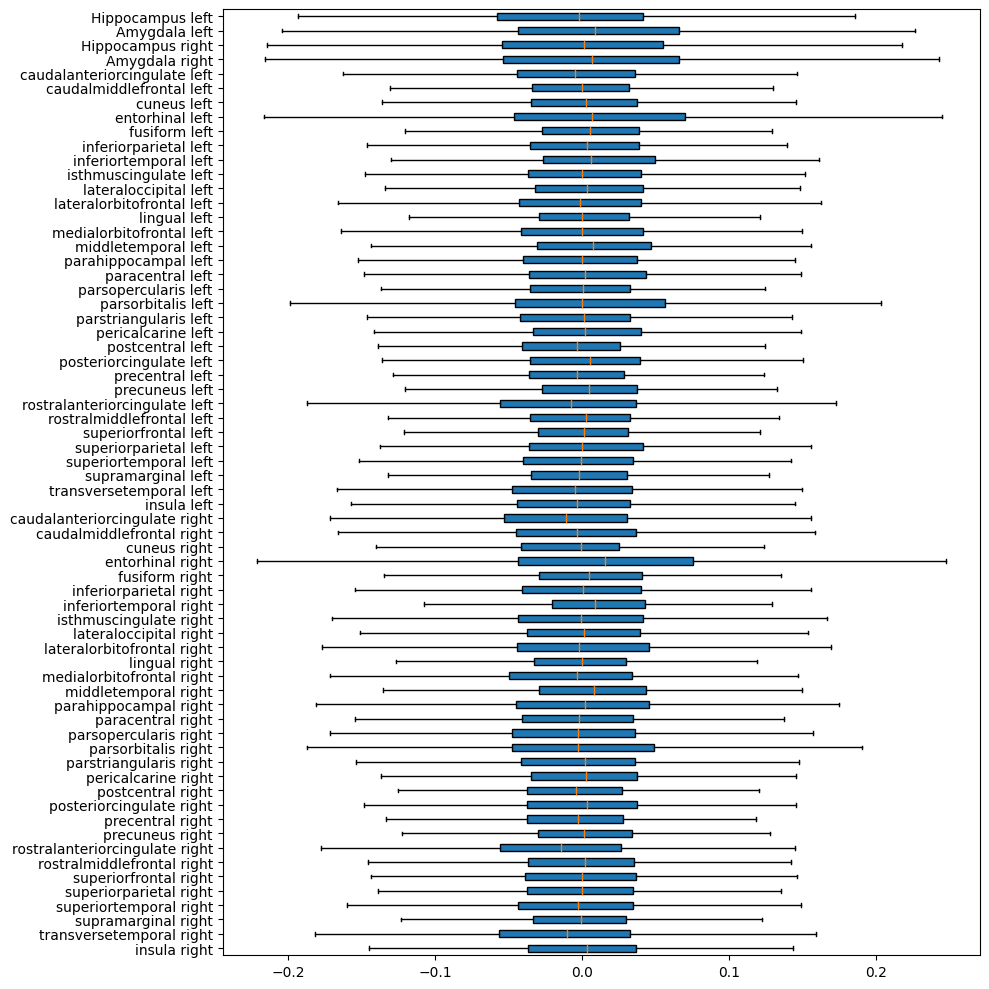

In [1236]:
roiwise_dsuvr_dataset = adni_paired_data[adni_paired_data['Ab status']==0.0]
roiwise_dsuvrs_df = pd.DataFrame({
                    'Name': (rois_66['ROI name']+' '+rois_66['Hemisphere']).tolist(),
                    'Mean': roiwise_dsuvr_dataset['dSUVR'].values.mean(),
                    'Std': roiwise_dsuvr_dataset['dSUVR'].values.std()
                    })
plt.figure(figsize=(10,10))
plt.boxplot(np.vstack(roiwise_dsuvr_dataset['dSUVR'].tolist())
            , vert=False, showfliers=False, patch_artist = True)
plt.gca().set_yticklabels((rois_66['ROI name']+' '+rois_66['Hemisphere']).tolist())
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [1238]:
roiwise_dsuvrs_df.sort_values(by='Mean', ascending = False).head(10)

,Name,Mean,Std
7,entorhinal left,0.011642,0.131362
1,Amygdala left,0.011311,0.159831
41,inferiortemporal right,0.011251,0.105346
3,Amygdala right,0.009456,0.176136
10,inferiortemporal left,0.009234,0.106496
12,lateraloccipital left,0.008822,0.105673
38,entorhinal right,0.008226,0.145944
16,middletemporal left,0.008156,0.103076
47,middletemporal right,0.007646,0.095724
8,fusiform left,0.006415,0.095726


In [1405]:
habs_paired_data.to_pickle('../data/66 ROIs processing HABS_ADNI/habs_paired_data.pkl')
adni_paired_data.to_pickle('../data/66 ROIs processing HABS_ADNI/adni_paired_data.pkl')

In [ ]:
#### convert to graph/geometric data for input to pytorch

In [1397]:
# create adjacency matrix

#HABS
habs_adjmat_112 = scipy.io.loadmat("../data/Input/one_A/A_one_0_w.mat")['A_one']
habs_adjmat_66 = adjmat_112[np.ix_(subset_rois_66, subset_rois_66)]

# ADNI
adni_adjmat_85 = scipy.io.loadmat("../data/Input/ADNI_CN_connectom.mat")['mean_50']
adni_adjmat_66 = adni_adjmat[np.ix_(map_85_to_66.flatten(), map_85_to_66.flatten())]

i, j = torch.meshgrid(torch.arange(66), torch.arange(66), indexing = 'ij')
edge_index = torch.stack([i.flatten(), j.flatten()], dim=0)
habs_edge_weight = torch.tensor([ [habs_adjmat_66[edge_index[0][index]][edge_index[1][index]]] 
               for index in range(edge_index[0].shape[0])])
adni_edge_weight = torch.tensor([ [adni_adjmat_66[edge_index[0][index]][edge_index[1][index]]] 
               for index in range(edge_index[0].shape[0])])

habs_edge_weight_norm = (habs_edge_weight - habs_edge_weight.min())/(habs_edge_weight.max() - habs_edge_weight.min())
adni_edge_weight_norm = (adni_edge_weight - adni_edge_weight.min())/(adni_edge_weight.max() - adni_edge_weight.min())

In [1398]:
torch.save(edge_index, '../data/66 ROIs processing HABS_ADNI/edge_index.pt')
torch.save(habs_edge_weight_norm, '../data/66 ROIs processing HABS_ADNI/habs_edge_weight.pt')
torch.save(adni_edge_weight_norm, '../data/66 ROIs processing HABS_ADNI/adni_edge_weight.pt')

In [1399]:
# create data objects

In [1406]:
def create_data_objects_list(paired_data, edge_weight, cohort):
    data_objects = []
    
    for index, row in paired_data.iterrows():
        subid = row['Subject ID']

        x = torch.tensor(row['Scaled Tau tp1'].reshape(-1, 1), dtype=torch.float)
        y = torch.tensor(row['Scaled Tau tp2'].reshape(-1, 1), dtype=torch.float)
        y = y-x

        data = Data(x=x, y=y, edge_index=edge_index, edge_weight=edge_weight)
        
        #additional info for this data object - identifiers
        data.cohort = cohort
        data.subid = subid
        data.tps = (row['tp1'], row['tp2'])

        data_objects.append(data)

    return data_objects


In [1407]:
implemented_edge_weight = adni_edge_weight_norm
torch.save(implemented_edge_weight, '../data/66 ROIs processing HABS_ADNI/implemented_edge_weight.pt')
habs_data_objects = create_data_objects_list(habs_paired_data, implemented_edge_weight, cohort = 'HABS')
adni_data_objects = create_data_objects_list(adni_paired_data, implemented_edge_weight, cohort = 'ADNI')
combined_data_objects = habs_data_objects + adni_data_objects

In [1408]:
def create_shuffled_split(current_data_objects, savename):
    subject_to_data = defaultdict(list)
    for data in current_data_objects:
        subject_to_data[data.subid].append(data)

    all_subjects = list(subject_to_data.keys())
    random.seed(42)
    random.shuffle(all_subjects)

    n = len(all_subjects)
    train_subjects = all_subjects[:int(0.7 * n)]
    val_subjects = all_subjects[int(0.7 * n):int(0.85 * n)]
    test_subjects = all_subjects[int(0.85 * n):]

    train_data = [data for sub in train_subjects for data in subject_to_data[sub]]
    val_data   = [data for sub in val_subjects for data in subject_to_data[sub]]
    test_data  = [data for sub in test_subjects for data in subject_to_data[sub]]
    
    torch.save(train_data, f'../data/66 ROIs processing HABS_ADNI/{savename}_train_data_objects.pt')
    torch.save(val_data, f'../data/66 ROIs processing HABS_ADNI/{savename}_val_data_objects.pt')
    torch.save(test_data, f'../data/66 ROIs processing HABS_ADNI/{savename}_test_data_objects.pt')
    
    return (train_data, val_data, test_data)

In [1409]:
train, val, test = create_shuffled_split(habs_data_objects, 'habs')
train, val, test = create_shuffled_split(adni_data_objects, 'adni')
train, val, test = create_shuffled_split(combined_data_objects, 'combined')

In [68]:
cohort = 'adni'

train_data = torch.load(f'../data/66 ROIs processing HABS_ADNI/{cohort}_train_data_objects.pt')
val_data = torch.load(f'../data/66 ROIs processing HABS_ADNI/{cohort}_val_data_objects.pt')
test_data = torch.load(f'../data/66 ROIs processing HABS_ADNI/{cohort}_test_data_objects.pt')

In [69]:
# adni_paired_data = pd.read_pickle('../data/66 ROIs processing HABS_ADNI/adni_paired_data.pkl')
adni_paired_data

,Subject ID,tp1,tp2,Age1,Age2,Age difference,Tau tp1,Tau tp2,Annualized Tau tp2,Scaled Tau tp1,Scaled Tau tp2,Scale Limits,dSUVR,Session ID tp1,Session ID tp2,Tau status,Ab status,Sex,Edu
0,002_S_1280,1,2,80.865161,81.842574,0.977413,"[1.269, 1.309, 1.278, 1.302, 1.031, 1.224, 1.2...","[1.263, 1.253, 1.254, 1.371, 0.968, 1.163, 1.2...","[1.2628613445378152, 1.2517058823529417, 1.253...","[0.6723044397463002, 0.7568710359408034, 0.691...","[0.6593263098051062, 0.635741823156325, 0.6394...","[0.951, 1.424]","[-0.012978129941193961, -0.12112921278447841, ...",I1593061,I1593074,1.0,1.0,2,14
1,002_S_4229,1,2,70.861054,72.506502,1.645448,"[1.087, 1.047, 1.079, 1.118, 1.114, 1.09, 1.2,...","[0.973, 1.011, 1.051, 1.067, 1.056, 1.044, 1.1...","[1.0177179700499166, 1.0251214642262894, 1.061...","[0.45088161209068006, 0.35012594458438273, 0.4...","[0.27636768274538187, 0.2950162826858674, 0.38...","[0.908, 1.305]","[-0.1745139293452982, -0.05510966189851535, -0...",I1593137,I1593026,0.0,0.0,1,15
2,002_S_4229,2,3,72.506502,73.500342,0.993840,"[0.973, 1.011, 1.051, 1.067, 1.056, 1.044, 1.1...","[0.98, 1.02, 1.027, 1.065, 1.026, 1.035, 1.149...","[0.980043388429752, 1.0200557851239669, 1.0268...","[0.2537313432835821, 0.34825870646766155, 0.44...","[0.27125221002425887, 0.37078553513424606, 0.3...","[0.871, 1.273]","[0.017520866740676766, 0.02252682866658451, -0...",I1593026,I1593122,0.0,0.0,1,15
3,002_S_4654,1,2,79.553730,80.585900,1.032170,"[1.562, 1.534, 1.71, 1.612, 1.122, 1.132, 1.19...","[1.494, 1.396, 1.504, 1.425, 1.088, 1.101, 1.2...","[1.4961193633952248, 1.4003010610079563, 1.510...","[0.7950138504155125, 0.7562326869806095, 1.0, ...","[0.7037664312953252, 0.5710541011190531, 0.723...","[0.988, 1.71]","[-0.0912474191201873, -0.18517858586155644, -0...",I1593062,I1593044,1.0,1.0,2,18
4,002_S_4654,2,3,80.585900,81.637235,1.051335,"[1.494, 1.396, 1.504, 1.425, 1.088, 1.101, 1.2...","[1.37, 1.331, 1.377, 1.303, 1.049, 1.061, 1.14...","[1.3760546875000002, 1.334173828125, 1.3832011...","[0.9809885931558935, 0.79467680608365, 1.0, 0....","[0.7567579610266163, 0.6771365553707224, 0.770...","[0.978, 1.504]","[-0.22423063212927719, -0.11754025071292762, -...",I1593044,I1593099,1.0,1.0,2,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,941_S_6580,2,3,81.007529,82.023272,1.015743,"[1.245, 1.365, 1.162, 1.197, 0.988, 1.012, 1.0...","[1.3, 1.465, 1.26, 1.313, 1.034, 1.057, 1.172,...","[1.299147574123989, 1.4634501347708893, 1.2584...","[0.7379912663755461, 1.0, 0.5567685589519649, ...","[0.8562174107510678, 1.2149566261373128, 0.767...","[0.907, 1.365]","[0.1182261443755217, 0.2149566261373128, 0.210...",I1603543,I1603427,0.0,1.0,2,18
780,941_S_6854,1,2,86.351814,87.482546,1.130732,"[1.725, 1.906, 1.643, 1.789, 1.061, 1.274, 1.2...","[1.776, 1.985, 1.73, 1.915, 1.102, 1.347, 1.28...","[1.7701035108958838, 1.9758662227602906, 1.719...","[0.6984126984126986, 0.8779761904761905, 0.617...","[0.7431582449363927, 0.9472879194050502, 0.693...","[1.021, 2.029]","[0.04474554652369411, 0.06931172892885973, 0.0...",I1603463,I1614584,1.0,1.0,1,18
781,941_S_6854,2,3,87.482546,88.309377,0.826831,"[1.776, 1.985, 1.73, 1.915, 1.102, 1.347, 1.28...","[1.801, 2.016, 1.689, 1.975, 1.124, 1.33, 1.21...","[1.8062359271523174, 2.0224925496688737, 1.680...","[0.5950819672131148, 0.7663934426229508, 0.557...","[0.6198655140592765, 0.7971250407121916, 0.516...","[1.05, 2.27]","[0.024783546846161686, 0.030731598089240753, -...",I1614584,I1614626,1.0,1.0,1,18
782,941_S_6962,1,2,74.877481,75.778234,0.900753,"[1.707, 1.815, 1.764, 1.984, 1.191, 1.173, 1.1...","[1.735, 2.014, 1.829, 2.125, 1.297, 1.314, 1.2...","[1.7380851063829792, 2.0359262917933147, 1.836...","[0.7218875502008033, 0.8303212851405622, 0.779...","[0.753097496368453, 1.0521348311177858, 0.8515...","[0.988, 1.984]","[0.031209946167649716, 0.22181354597722358, 0....",I1614523,I1623496,1.0,1.0,2,12


In [70]:
cohort = 'adni'
train_data = torch.load(f'../data/66 ROIs processing HABS_ADNI/{cohort}_train_data_objects.pt')
val_data = torch.load(f'../data/66 ROIs processing HABS_ADNI/{cohort}_val_data_objects.pt')
test_data = torch.load(f'../data/66 ROIs processing HABS_ADNI/{cohort}_test_data_objects.pt')

In [71]:
train_ids = sorted({d.subid for d in train_data})
val_ids   = sorted({d.subid for d in val_data})
test_ids  = sorted({d.subid for d in test_data})

In [72]:
import pandas as pd

# =========================================================
# 1. Extract unique subject IDs from each split
# =========================================================
train_ids = sorted({d.subid for d in train_data})
val_ids   = sorted({d.subid for d in val_data})
test_ids  = sorted({d.subid for d in test_data})

all_ids = sorted(set(train_ids) | set(val_ids) | set(test_ids))

# =========================================================
# 2. Helper: get scan-level and subject-level dfs for a split
#    subject-level is used for demographics
#    scan-level is used for scan counts
# =========================================================
def get_split_dfs(df, subject_ids):
    split_scan_df = df[df['Subject ID'].isin(subject_ids)].copy()
    
    # Sort so "first" is deterministic
    sort_cols = [c for c in ['Subject ID', 'tp1', 'tp2'] if c in split_scan_df.columns]
    split_scan_df = split_scan_df.sort_values(sort_cols)
    
    # One row per subject for demographic info
    split_subject_df = split_scan_df.groupby('Subject ID', as_index=False).first()
    
    return split_scan_df, split_subject_df

train_scan_df, train_subj_df = get_split_dfs(adni_paired_data, train_ids)
val_scan_df, val_subj_df     = get_split_dfs(adni_paired_data, val_ids)
test_scan_df, test_subj_df   = get_split_dfs(adni_paired_data, test_ids)
all_scan_df, all_subj_df     = get_split_dfs(adni_paired_data, all_ids)

# =========================================================
# 3. Sanity checks
# =========================================================
print("Subjects per split:")
print("Train:", len(train_ids))
print("Val:", len(val_ids))
print("Test:", len(test_ids))
print("Total unique:", len(all_ids))

print("\nSex coding counts in full dataframe:")
print(adni_paired_data['Sex'].value_counts(dropna=False))

print("\nCheck sex consistency within subject:")
print(adni_paired_data.groupby('Subject ID')['Sex'].nunique().value_counts())

Subjects per split:
Train: 323
Val: 69
Test: 70
Total unique: 462

Sex coding counts in full dataframe:
Sex
2    402
1    377
Name: count, dtype: int64

Check sex consistency within subject:
Sex
1    462
Name: count, dtype: int64


In [77]:
all_subj_df

,Subject ID,tp1,tp2,Age1,Age2,Age difference,Tau tp1,Tau tp2,Annualized Tau tp2,Scaled Tau tp1,Scaled Tau tp2,Scale Limits,dSUVR,Session ID tp1,Session ID tp2,Tau status,Ab status,Sex,Edu
0,002_S_1280,1,2,80.865161,81.842574,0.977413,"[1.269, 1.309, 1.278, 1.302, 1.031, 1.224, 1.2...","[1.263, 1.253, 1.254, 1.371, 0.968, 1.163, 1.2...","[1.2628613445378152, 1.2517058823529417, 1.253...","[0.6723044397463002, 0.7568710359408034, 0.691...","[0.6593263098051062, 0.635741823156325, 0.6394...","[0.951, 1.424]","[-0.012978129941193961, -0.12112921278447841, ...",I1593061,I1593074,1.0,1.0,2,14
1,002_S_4229,1,2,70.861054,72.506502,1.645448,"[1.087, 1.047, 1.079, 1.118, 1.114, 1.09, 1.2,...","[0.973, 1.011, 1.051, 1.067, 1.056, 1.044, 1.1...","[1.0177179700499166, 1.0251214642262894, 1.061...","[0.45088161209068006, 0.35012594458438273, 0.4...","[0.27636768274538187, 0.2950162826858674, 0.38...","[0.908, 1.305]","[-0.1745139293452982, -0.05510966189851535, -0...",I1593137,I1593026,0.0,0.0,1,15
2,002_S_4654,1,2,79.553730,80.585900,1.032170,"[1.562, 1.534, 1.71, 1.612, 1.122, 1.132, 1.19...","[1.494, 1.396, 1.504, 1.425, 1.088, 1.101, 1.2...","[1.4961193633952248, 1.4003010610079563, 1.510...","[0.7950138504155125, 0.7562326869806095, 1.0, ...","[0.7037664312953252, 0.5710541011190531, 0.723...","[0.988, 1.71]","[-0.0912474191201873, -0.18517858586155644, -0...",I1593062,I1593044,1.0,1.0,2,18
3,002_S_4799,1,2,72.153320,72.971937,0.818617,"[1.28, 1.37, 1.26, 1.328, 1.161, 1.162, 1.136,...","[1.28, 1.302, 1.252, 1.256, 1.131, 1.006, 1.07...","[1.28, 1.2869331103678927, 1.2502274247491638,...","[0.7846889952153109, 1.0, 0.7368421052631577, ...","[0.7846889952153109, 0.8012753836552455, 0.713...","[0.952, 1.37]","[0.0, -0.19872461634475447, -0.023379366628794...",I1593040,I1593068,0.0,1.0,1,14
4,002_S_5230,1,2,77.686516,78.817248,1.130732,"[1.163, 1.157, 1.329, 1.366, 1.026, 1.318, 1.1...","[1.114, 1.117, 1.321, 1.474, 1.065, 1.369, 1.2...","[1.1196652542372882, 1.1216246973365618, 1.321...","[0.0775669642857143, 0.07421875000000001, 0.17...","[0.053384628480629595, 0.054478067710134914, 0...","[1.024, 2.816]","[-0.024182335805084706, -0.0197406822898651, -...",I1593138,I1593125,1.0,1.0,2,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,941_S_6575,1,2,73.648186,74.548939,0.900753,"[1.233, 1.304, 1.254, 1.385, 1.01, 1.033, 1.07...","[1.196, 1.294, 1.242, 1.389, 1.079, 1.058, 1.1...","[1.1919232522796348, 1.2928981762917933, 1.240...","[0.6529680365296806, 0.8150684931506851, 0.700...","[0.5591855074877508, 0.7897218636798933, 0.670...","[0.947, 1.385]","[-0.09378252904192985, -0.025346629470791804, ...",I1603451,I1603425,0.0,1.0,1,20
458,941_S_6580,1,2,80.068446,81.007529,0.939083,"[1.244, 1.362, 1.17, 1.21, 1.024, 1.061, 1.105...","[1.245, 1.365, 1.162, 1.197, 0.988, 1.012, 1.0...","[1.2450648688046648, 1.3651946064139941, 1.161...","[0.7489361702127658, 1.0, 0.5914893617021274, ...","[0.7512018485205633, 1.0067970349233917, 0.573...","[0.892, 1.362]","[0.0022656783077974474, 0.006797034923391676, ...",I1603592,I1603543,0.0,1.0,2,18
459,941_S_6854,1,2,86.351814,87.482546,1.130732,"[1.725, 1.906, 1.643, 1.789, 1.061, 1.274, 1.2...","[1.776, 1.985, 1.73, 1.915, 1.102, 1.347, 1.28...","[1.7701035108958838, 1.9758662227602906, 1.719...","[0.6984126984126986, 0.8779761904761905, 0.617...","[0.7431582449363927, 0.9472879194050502, 0.693...","[1.021, 2.029]","[0.04474554652369411, 0.06931172892885973, 0.0...",I1603463,I1614584,1.0,1.0,1,18
460,941_S_6962,1,2,74.877481,75.778234,0.900753,"[1.707, 1.815, 1.764, 1.984, 1.191, 1.173, 1.1...","[1.735, 2.014, 1.829, 2.125, 1.297, 1.314, 1.2...","[1.7380851063829792, 2.0359262917933147, 1.836...","[0.7218875502008033, 0.8303212851405622, 0.779...","[0.753097496368453, 1.0521348311177858, 0.8515...","[0.988, 1.984]","[0.031209946167649716, 0.22181354597722358, 0....",I1614523,I1623496,1.0,1.0,2,12


In [97]:
len(test_scan_df), len(test_subj_df), np.array(test_subj_df['Age1']).mean(), np.array(test_subj_df['Age1']).std()

(123, 70, 72.86234477363841, 7.162053254206324)

In [98]:
np.array(test_subj_df['Edu']).mean(), np.array(test_subj_df['Edu']).std()

(16.37142857142857, 2.4270583521823204)

In [99]:
test_subj_df['Sex'].value_counts(dropna=False)

Sex
2    36
1    34
Name: count, dtype: int64